# 13_02.Tensorflow(최적 모델)
- https://www.tensorflow.org/tutorials/keras/save_and_load?hl=ko

## 1.기본 package 설정

In [1]:
import numpy as np  # numpy 패키지 가져오기
import matplotlib.pyplot as plt # 시각화 패키지 가져오기

import tensorflow as tf
from tensorflow import keras
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.12.0


## 2.데이터 불러오기

### 2.1 데이터 불러오기

In [2]:
(X_train, y_train),(X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 [==============================] - 2s 0us/step


### 2.2 자료구조 살펴보기

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True,)

ax = ax.flatten()

for i in range(10):
    img = X_train[y_train == i][0].reshape(28,28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True,)

ax = ax.flatten()

for i in range(25):
    img = X_train[y_train == 7][i].reshape(28,28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [ ]:
X_train[y_train == 0][0]

In [ ]:
print(X_train.shape, X_train.dtype)
print(X_test.shape, X_test.dtype)

## 3.신경망

### 3.1 신경망 구성


In [4]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(50, activation='relu'),      # 784*50+50(절편)
    tf.keras.layers.Dense(50, activation='relu'),      # 784*50+50(절편)
    tf.keras.layers.Dropout(0.2),                      # 과적합방지
    # 각 클래스의 확률을 계산하기 위해 softmax 사용
    tf.keras.layers.Dense(10, activation='softmax')
])

In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 50)                39250     
                                                                 
 dense_1 (Dense)             (None, 50)                2550      
                                                                 
 dropout (Dropout)           (None, 50)                0         
                                                                 
 dense_2 (Dense)             (None, 10)                510       
                                                                 
Total params: 42,310
Trainable params: 42,310
Non-trainable params: 0
_________________________________________________________________


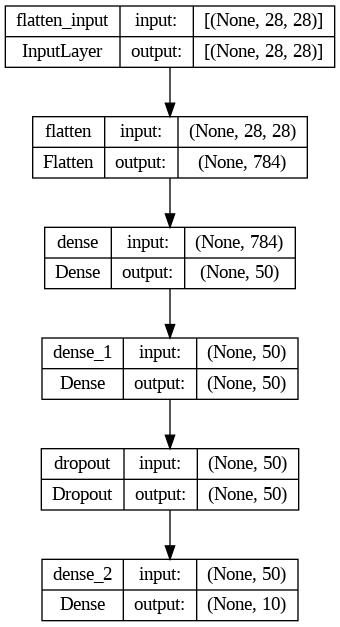

In [6]:
tf.keras.utils.plot_model(model,
                          show_shapes = True,
                          to_file='model.png')

### 3.2 신경망 훈련
- 이진 분류 : binary_crossentropy
- 다중 분류 : sparse_categorical_crossentropy

In [7]:
!pip install pyyaml h5py  # 훈련 모델을 HDF5 format으로 저장

In [15]:
# 훈련 모델 저장후 최적 모델을 추출

import os
checkpoint_path = "training_1/cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

callback_list = [tf.keras.callbacks.ModelCheckpoint(filepath = checkpoint_path,
                                                    save_best_only = True,
                                                    verbose = 1),
               tf.keras.callbacks.EarlyStopping(patience = 5)]

In [16]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
np.random.seed(1)

history = model.fit(X_train,
                    y_train,
                    batch_size=64,
                    epochs=10,
                    validation_split=0.1, # 검증용 데이터 10% 추출해서 훈련시 검정
                    callbacks = callback_list)

Epoch 1/10
844/844 [==============================] - ETA: 0s - loss: 0.2471 - accuracy: 0.9325
Epoch 1: val_loss improved from inf to 0.20962, saving model to training_1/cp.ckpt
844/844 [==============================] - 5s 4ms/step - loss: 0.2471 - accuracy: 0.9325 - val_loss: 0.2096 - val_accuracy: 0.9592
Epoch 2/10
840/844 [============================>.] - ETA: 0s - loss: 0.2301 - accuracy: 0.9368
Epoch 2: val_loss improved from 0.20962 to 0.17791, saving model to training_1/cp.ckpt
844/844 [==============================] - 4s 4ms/step - loss: 0.2303 - accuracy: 0.9368 - val_loss: 0.1779 - val_accuracy: 0.9595
Epoch 3/10
840/844 [============================>.] - ETA: 0s - loss: 0.2168 - accuracy: 0.9414
Epoch 3: val_loss improved from 0.17791 to 0.16139, saving model to training_1/cp.ckpt
844/844 [==============================] - 4s 5ms/step - loss: 0.2168 - accuracy: 0.9413 - val_loss: 0.1614 - val_accuracy: 0.9597
Epoch 4/10
836/844 [============================>.] - ETA: 0s 

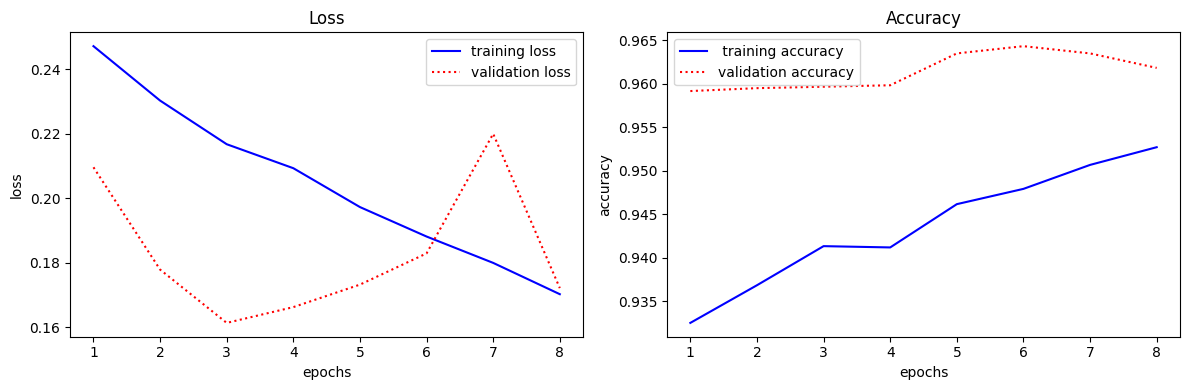

In [18]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs = range(1, len(loss)+1)


plt.figure(figsize=(12, 4))

# 비용함수
plt.subplot(1, 2, 1)
plt.title("Loss")
plt.xlabel('epochs')
plt.ylabel('loss')
plt.plot(epochs, loss, 'b-', label='training loss')
plt.plot(epochs, val_loss, 'r:', label='validation loss')
plt.legend()

# 정확도
plt.subplot(1, 2, 2)
plt.title("Accuracy")
plt.ylabel("accuracy")
plt.xlabel('epochs')
plt.plot(epochs, accuracy, 'b-', label=" training accuracy")
plt.plot(epochs, val_accuracy, 'r:', label="validation accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## 4.모델검정


In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('test 비용: %.4f%%' % (100 * test_loss))
print('test 정확도: %.4f%%' % (100 * test_acc))

313/313 [==============================] - 1s 2ms/step - loss: 0.2000 - accuracy: 0.9552
test 비용: 20.0047%
test 정확도: 95.5200%


In [20]:
model.load_weights(checkpoint_path)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print('best 모델, test 비용: %.4f%%' % (100 * test_loss))
print('best 모델, test 정확도: %.4f%%' % (100 * test_acc))

313/313 - 1s - loss: 0.1919 - accuracy: 0.9521 - 573ms/epoch - 2ms/step
best 모델, test 비용: 19.1937%
best 모델, test 정확도: 95.2100%


## 5.모델 저장하기
- 모델 저장해서 활용하기

In [ ]:
model.save('my_model.h5')

In [ ]:
new_model = tf.keras.models.load_model('my_model.h5')

new_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 50)                39250     
                                                                 
 dense_1 (Dense)             (None, 50)                2550      
                                                                 
 dropout (Dropout)           (None, 50)                0         
                                                                 
 dense_2 (Dense)             (None, 10)                510       
                                                                 
Total params: 42,310
Trainable params: 42,310
Non-trainable params: 0
_________________________________________________________________
